# Machine Learning-Based Permeability Prediction

This notebook presents the workflow used for permeability prediction from well-log data.

The analysis includes:

- Data loading and exploration
- Data preparation and well merging
- Logarithmic transformation of permeability
- Training and test dataset preparation
- Correlation and exploratory analysis
- Feature preprocessing
- Baseline Random Forest, SVR, and XGBoost models
- Five-fold cross-validation
- Learning-curve analysis
- Hyperparameter tuning
- Final model evaluation
- Actual versus predicted permeability visualization

The target variable is the base-10 logarithm of permeability, logK.

In [7]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [8]:
from pathlib import Path

print(Path.cwd())

c:\Users\private\Permeability-Prediction\notebooks


In [10]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from src.data_processing import load_well_data, combine_wells, create_logK
from src.preprocessing import create_preprocessor
from src.models import build_models
from src.training import cross_validate_model, train_model
from src.tuning import tune_random_forest, tune_xgboost, tune_svr
from src.evaluation import regression_metrics
from src.viualisation import plot_learning_curve, plot_correlation_with_logk, plot_pairplot, scatter_plot


In [11]:
print(sys.executable)

c:\Users\private\Permeability-Prediction\.venv\Scripts\python.exe


## Data Loading

Two well datasets, P4 and P5, are loaded from CSV files. Missing values represented by -999.25 are interpreted as NaN.

In [13]:
p4_df = load_well_data("../data/K_puit_4.csv")
p5_df = load_well_data("../data/k_puit_5.csv")

In [14]:
print("\nP4 file:")
display(p4_df.head())

print("\nP5 file:")
display(p5_df.tail())


P4 file:


,DEPTH,CAL,DT,GR,NPHI,ILD,RHOB,SP,porosite,K
0,1125.00000,9.42400,132.83900,64.94500,0.45300,1.12700,2.23200,1.97700,0.297697,2660.124633
1,1125.00476,9.42488,132.79199,64.95374,0.45279,1.12912,2.23250,1.97772,0.297402,2655.458014
2,1125.19995,9.46158,130.86328,65.31360,0.44420,1.21579,2.25279,2.00739,0.285378,2469.408388
3,1125.20007,9.46161,130.86230,65.31384,0.44420,1.21585,2.25281,2.00742,0.285371,2469.303368
4,1125.21558,9.46452,130.70898,65.34241,0.44352,1.22272,2.25442,2.00977,0.284423,2454.948991



P5 file:


,DEPTH,CAL,DT,GR,NPHI,ILD,RHOB,SP,porosite,K
1306,1185.59998,9.87378,128.60742,93.81055,0.44678,0.94019,2.15060,5.30283,0.148471,892.298514
1307,1185.60010,9.87366,128.60645,93.80859,0.44678,0.94025,2.15060,5.30276,0.148483,892.394274
1308,1185.67200,9.79810,128.00488,92.66992,0.45062,0.97559,2.15031,5.27313,0.156094,953.941625
1309,1185.75000,9.71600,127.35200,91.43600,0.45478,10.01400,2.15000,5.24100,0.163985,1021.014288
1310,1185.75208,9.71362,127.31250,91.42529,0.45479,10.01421,2.15025,5.24219,0.164013,1021.258598


## Exploratory Data Analysis

The datasets were inspected using basic information, descriptive statistics, and histograms to understand their structure and distributions.

In [15]:
p4_df.info()
p5_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 465 entries, 0 to 464
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   DEPTH     465 non-null    float64
 1   CAL       465 non-null    float64
 2   DT        465 non-null    float64
 3   GR        465 non-null    float64
 4   NPHI      465 non-null    float64
 5   ILD       465 non-null    float64
 6   RHOB      465 non-null    float64
 7   SP        465 non-null    float64
 8   porosite  465 non-null    float64
 9   K         465 non-null    float64
dtypes: float64(10)
memory usage: 36.5 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1311 entries, 0 to 1310
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   DEPTH     1311 non-null   float64
 1   CAL       1311 non-null   float64
 2   DT        1311 non-null   float64
 3   GR        1311 non-null   float64
 4   NPHI      1311 non-null   float64
 5   

In [16]:
display(p4_df.describe())
display(p5_df.describe())

,DEPTH,CAL,DT,GR,NPHI,ILD,RHOB,SP,porosite,K
count,465.000000,465.000000,465.000000,465.000000,465.000000,465.000000,465.000000,465.000000,465.000000,465.000000
mean,1142.178649,9.540777,138.926198,67.332782,0.381195,4.310623,2.148902,1.212216,0.219523,1684.011165
std,10.174133,0.167223,15.611941,8.835213,0.114910,6.057910,0.134669,1.204882,0.060652,707.954358
min,1125.000000,9.188000,114.583000,44.727000,0.095000,0.858000,1.823000,-0.864000,0.000000,307.000000
25%,1133.400020,9.446000,127.355830,62.757000,0.319670,1.215970,2.084000,-0.070010,0.191140,1277.059352
50%,1142.200070,9.495000,132.791990,70.209960,0.426750,1.394190,2.202400,1.613590,0.214616,1529.979817
75%,1150.996830,9.642000,150.032000,73.767330,0.464600,4.795000,2.242190,2.297610,0.258242,2077.714359
max,1159.800050,10.088000,187.802990,82.580000,0.551000,24.709000,2.425000,3.070000,0.398403,4521.460509


,DEPTH,CAL,DT,GR,NPHI,ILD,RHOB,SP,porosite,K
count,1311.000000,1311.000000,1311.000000,1311.000000,1311.000000,1311.000000,1311.000000,1311.000000,1311.000000,1311.000000
mean,1158.927756,10.413211,141.219155,85.966068,0.471433,1.461860,2.129146,6.121619,0.193310,1394.664418
std,15.517484,0.650700,6.669195,9.734950,0.040601,2.536441,0.041673,1.619323,0.059983,549.253596
min,1132.027220,9.214000,124.002000,56.954000,0.348430,0.597000,1.983000,-0.439000,0.000000,307.000000
25%,1145.520630,9.882000,136.714465,78.934080,0.445540,0.643265,2.103160,5.750380,0.146026,873.186980
50%,1159.000000,10.263010,143.388670,83.262700,0.479880,0.682000,2.138600,6.914000,0.215437,1539.346337
75%,1172.330380,10.955350,145.246215,94.334025,0.504595,0.853415,2.159190,7.087255,0.239668,1832.155125
max,1185.752080,11.875000,159.322010,108.752000,0.535740,10.685000,2.205000,7.573000,0.287415,2500.389715


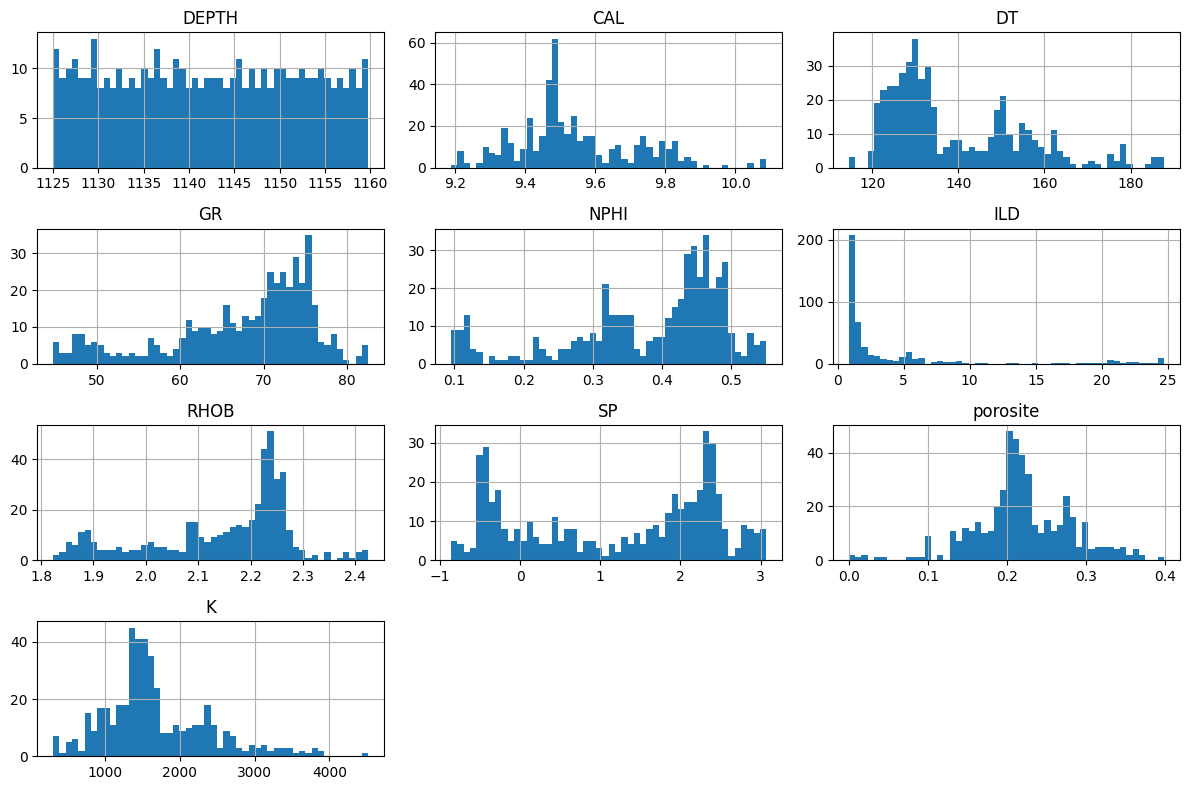

In [17]:
p4_df.hist(bins=50, figsize=(12, 8))
plt.tight_layout()
plt.show()

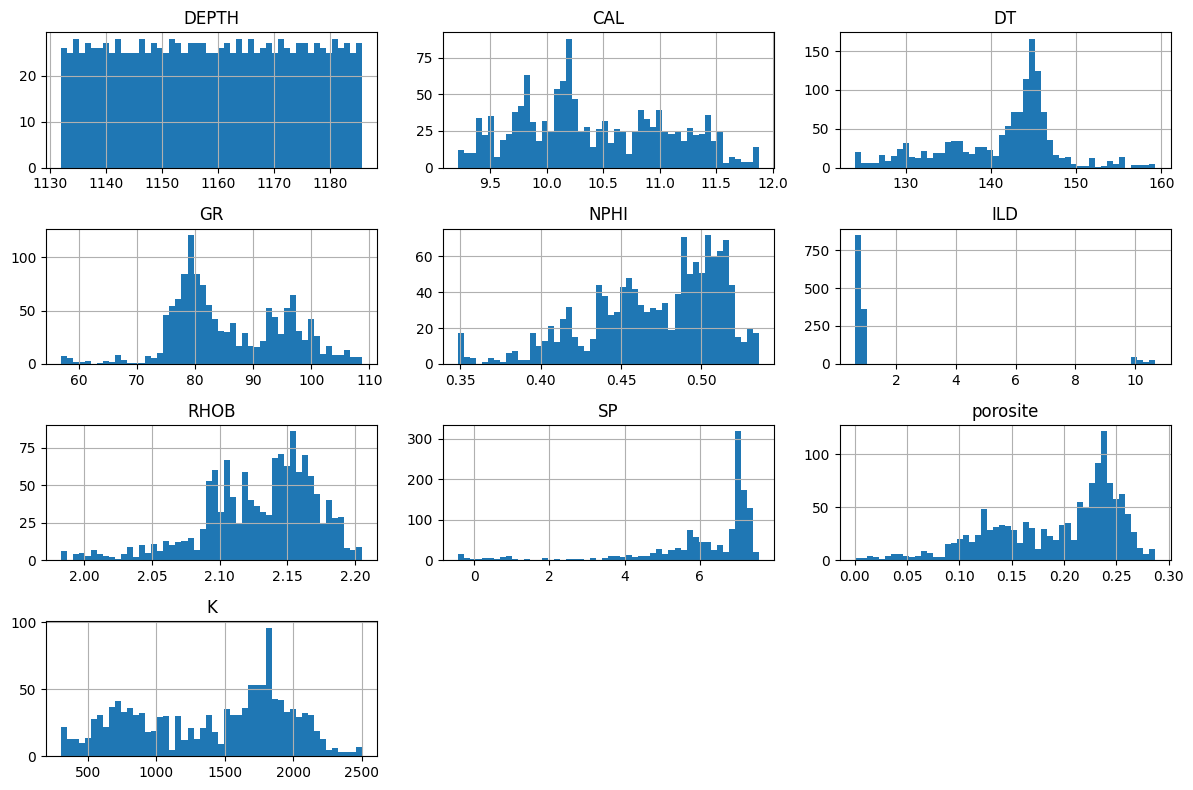

In [18]:
p5_df.hist(bins=50, figsize=(12, 8))
plt.tight_layout()
plt.show()

## Combining the P4 and P5 Well Data

The P4 and P5 datasets were combined into a single dataset. A well identifier was retained to distinguish observations originating from each well.

In [19]:
wells = combine_wells([p5_df, p4_df], ["p5", "p4"])

In [20]:
display(wells.head())
display(wells.tail())

,DEPTH,CAL,DT,GR,NPHI,ILD,RHOB,SP,porosite,K,Well Name
0,1132.02722,11.35504,144.35498,85.66113,0.50875,0.67578,2.13850,7.36130,0.211634,1496.225529,p5
1,1132.17957,11.42816,143.96240,83.76367,0.50610,0.67456,2.15252,7.34058,0.217967,1568.458648,p5
2,1132.19995,11.43793,143.90991,83.50977,0.50575,0.67440,2.15440,7.33780,0.218750,1577.543693,p5
3,1132.20007,11.43799,143.90967,83.50879,0.50575,0.67440,2.15440,7.33778,0.218755,1577.592858,p5
4,1132.25000,11.46200,143.78101,82.88700,0.50488,0.67400,2.15900,7.33100,0.220610,1599.233597,p5


,DEPTH,CAL,DT,GR,NPHI,ILD,RHOB,SP,porosite,K,Well Name
1771,1159.59314,9.40128,140.87402,70.49915,0.54131,1.34649,1.97829,2.80908,0.293467,2593.729313,p4
1772,1159.59998,9.39960,140.90479,70.50732,0.54060,1.34660,1.97919,2.80960,0.278081,2360.238460,p4
1773,1159.75000,9.36300,141.58000,70.68800,0.52500,1.34900,1.99900,2.82100,0.275083,2316.202847,p4
1774,1159.79187,9.36451,141.07324,71.37500,0.52248,1.33344,2.02985,2.83728,0.202457,1395.328101,p4
1775,1159.80005,9.36480,140.97363,71.50781,0.52200,1.33038,2.03589,2.84045,0.199655,1365.419065,p4


## Permeability Transformation

Depth was excluded from the predictor variables.

Permeability values ranged approximately from 300 to 4500 mD. A base-10 logarithmic transformation was applied to permeability to obtain the target variable logK.

In [21]:
wells_no_depth = create_logK(wells)

In [22]:
display(wells_no_depth.head())

,CAL,DT,GR,NPHI,ILD,RHOB,SP,porosite,K,Well Name,logK
0,11.35504,144.35498,85.66113,0.50875,0.67578,2.13850,7.36130,0.211634,1496.225529,p5,3.174997
1,11.42816,143.96240,83.76367,0.50610,0.67456,2.15252,7.34058,0.217967,1568.458648,p5,3.195473
2,11.43793,143.90991,83.50977,0.50575,0.67440,2.15440,7.33780,0.218750,1577.543693,p5,3.197981
3,11.43799,143.90967,83.50879,0.50575,0.67440,2.15440,7.33778,0.218755,1577.592858,p5,3.197995
4,11.46200,143.78101,82.88700,0.50488,0.67400,2.15900,7.33100,0.220610,1599.233597,p5,3.203912


## Features and Target Variable

The predictor variables consisted of the well-log measurements CAL, DT, GR, NPHI, ILD, RHOB, and SP, together with the well identifier used for stratification during the train-test split.

The prediction target was logK.

In [23]:
feature_variable = ["CAL", "DT", "GR", "NPHI", "ILD", "RHOB", "SP", "Well Name"]

X = wells_no_depth[feature_variable]
y_perm = wells_no_depth["logK"]
y_porosity = wells_no_depth["porosite"]

## Training and Test Data

The dataset was divided into training and test subsets using a fixed random state of 42. Stratification by well name was used to maintain the representation of both wells in the resulting subsets.

In [24]:
X_train_perm, X_test_perm, y_train_perm, y_test_perm = train_test_split(
    X,
    y_perm,
    stratify=wells_no_depth["Well Name"],
    random_state=42
)

In [25]:
X_train_perm = X_train_perm.drop("Well Name", axis=1)
X_test_perm = X_test_perm.drop("Well Name", axis=1)

## Correlation Analysis

The correlations between the numerical variables and logK were examined to investigate the relationships between well-log measurements and permeability.

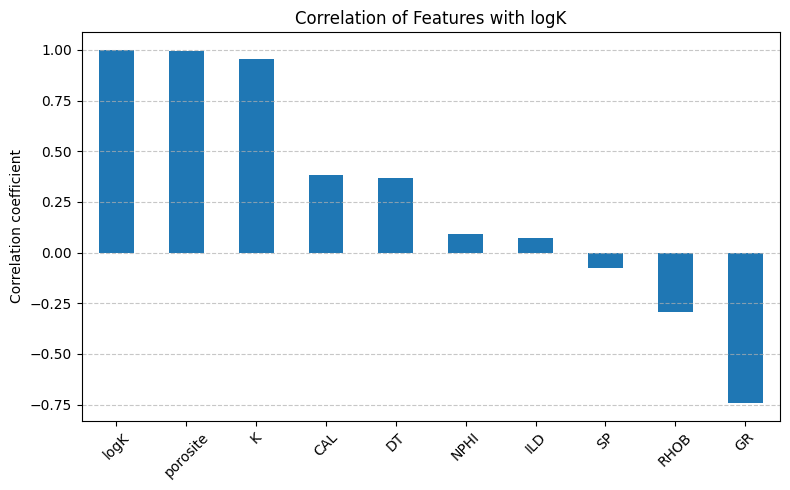

In [26]:
plot_correlation_with_logk(wells_no_depth)

## Pairwise Feature Relationships

Pairwise relationships between selected well-log variables and logK were visualized to further explore the data.

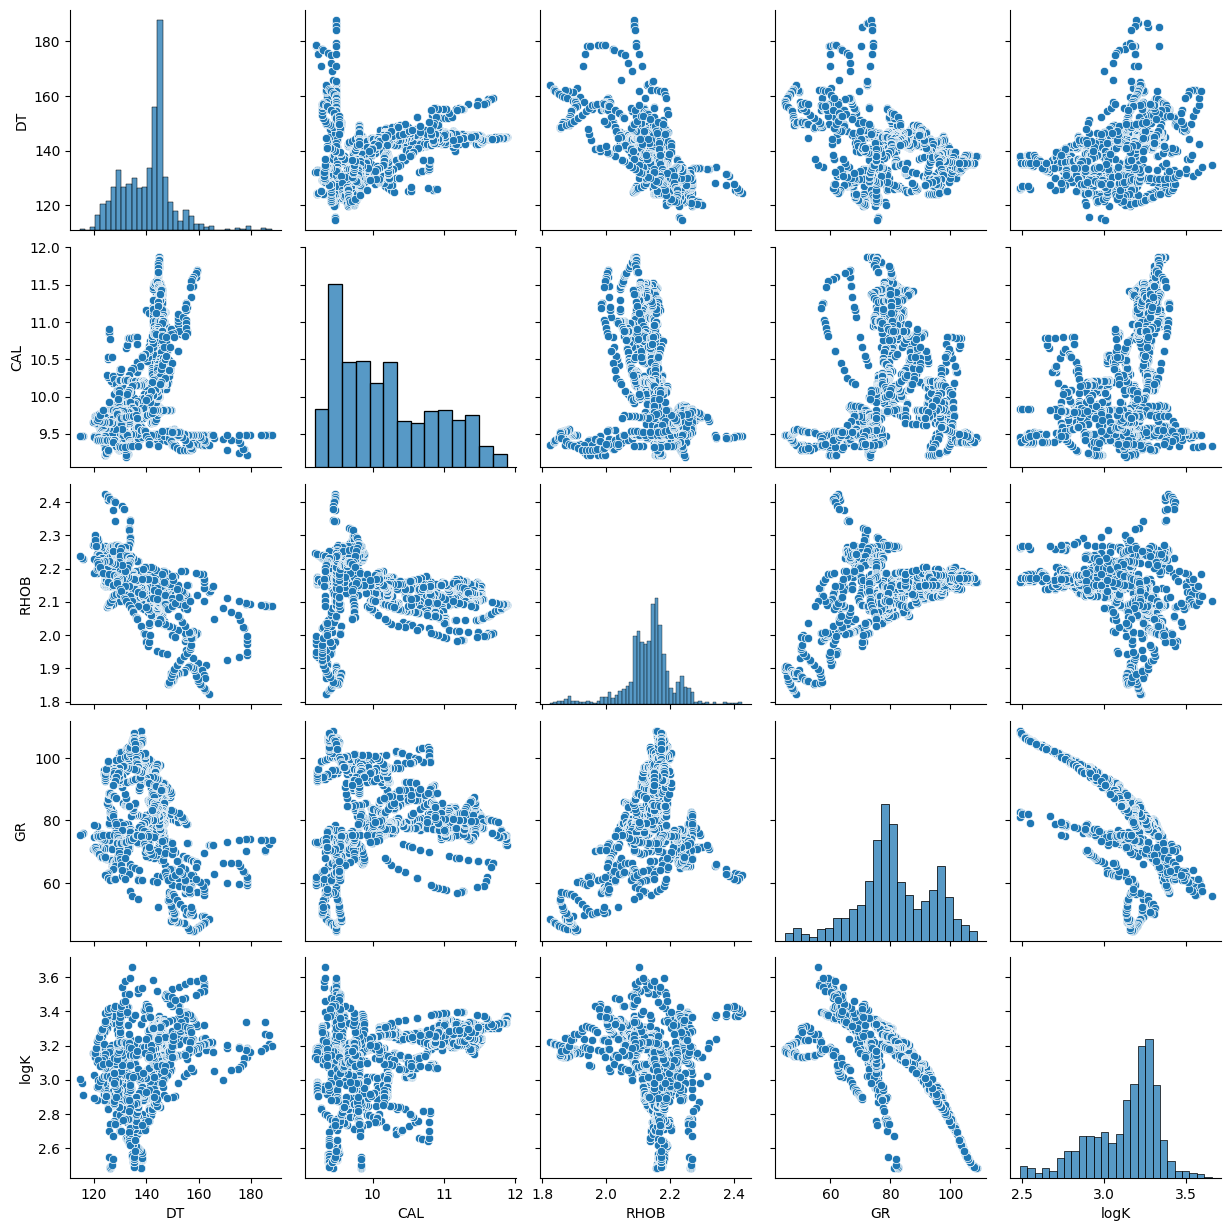

In [27]:
plot_pairplot(wells_no_depth, ["DT", "CAL", "RHOB", "GR", "logK"])

## Feature Scaling and Transformation

Missing values were handled using K-nearest-neighbor imputation.

The variables CAL, DT, GR, NPHI, RHOB, and SP were imputed and standardized.

ILD was imputed, transformed using a base-10 logarithm, and subsequently standardized.

The preprocessing operations were implemented as a scikit-learn pipeline to ensure that the same transformations were applied consistently during model training, cross-validation, hyperparameter tuning, and testing.

In [28]:
preprocessing_1 = create_preprocessor()

## Baseline Machine Learning Models

Three regression algorithms were considered:

1. Random Forest Regression
2. Support Vector Regression (SVR)
3. XGBoost Regression

The initial models were evaluated before hyperparameter tuning.

In [29]:
models = build_models(preprocessing_1)

## Baseline Model Evaluation Using 5-Fold Cross-Validation

The baseline models were evaluated using five-fold cross-validation with root mean squared error (RMSE) as the evaluation metric.

In [30]:
baseline_scores = {}

for name, model in models.items():

    scores = cross_validate_model(model, X_train_perm, y_train_perm, cv=5)

    baseline_scores[name] = scores

    print(f"\n{name}")
    print(pd.Series(scores).describe())


RandomForest
count    5.000000
mean     0.033986
std      0.012706
min      0.023424
25%      0.024517
50%      0.030489
75%      0.036932
max      0.054568
dtype: float64

SVR
count    5.000000
mean     0.063960
std      0.002255
min      0.060832
25%      0.063288
50%      0.063568
75%      0.065294
max      0.066819
dtype: float64

XGBoost
count    5.000000
mean     0.030946
std      0.011585
min      0.020261
25%      0.024088
50%      0.024282
75%      0.038680
max      0.047419
dtype: float64


## Learning Curve Analysis

Learning curves were generated to assess training and validation performance as a function of training-set size and to investigate potential underfitting or overfitting behavior.

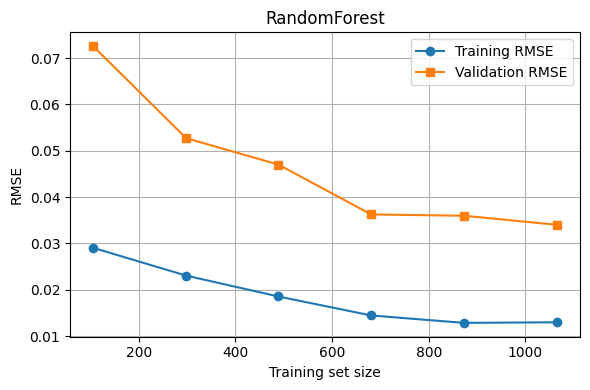

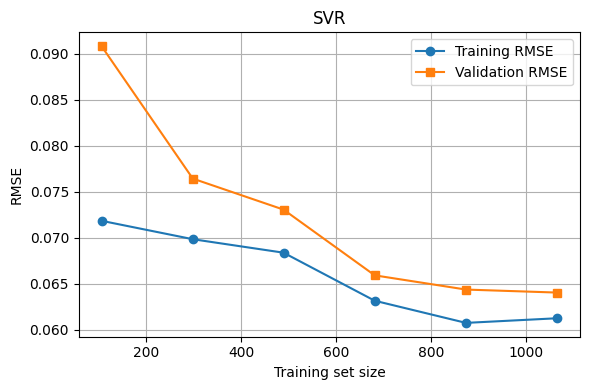

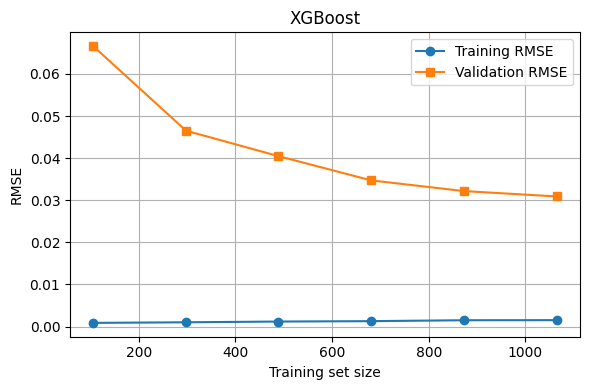

In [31]:
for name, model in models.items():
    plot_learning_curve(model, X_train_perm, y_train_perm, name)

## Random Forest Hyperparameter Tuning

RandomizedSearchCV with five-fold cross-validation was used to search for an improved Random Forest configuration.

The hyperparameters considered were:

- Number of estimators
- Maximum tree depth
- Minimum samples required for splitting
- Minimum samples per leaf
- Maximum number of features
- Bootstrap sampling

In [32]:
rf_random_search = tune_random_forest(preprocessing_1)

In [33]:
rf_random_search.fit(X_train_perm, y_train_perm)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'rf_reg__bootstrap': [True, False], 'rf_reg__max_depth': [3, 4, ...], 'rf_reg__max_features': ['sqrt', 'log2', ...], 'rf_reg__min_samples_leaf': [1, 2], ...}"
,n_iter,30
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [34]:
rf_random_search.fit(X_train_perm, y_train_perm)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'rf_reg__bootstrap': [True, False], 'rf_reg__max_depth': [3, 4, ...], 'rf_reg__max_features': ['sqrt', 'log2', ...], 'rf_reg__min_samples_leaf': [1, 2], ...}"
,n_iter,30
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [35]:
final_model = rf_random_search.best_estimator_

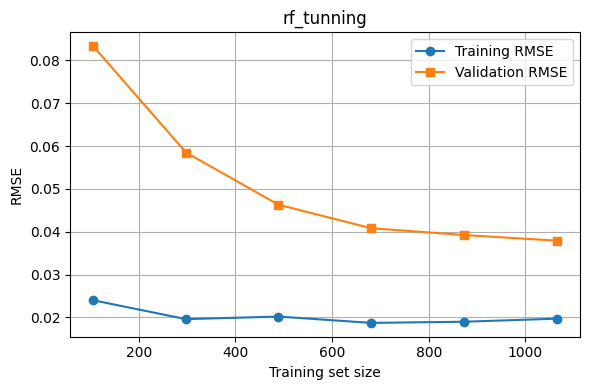

In [36]:
plot_learning_curve(final_model, X_train_perm, y_train_perm, "rf_tunning")

## Random Forest Test Evaluation

The optimized Random Forest model was evaluated on the test dataset that was not used during model training or hyperparameter optimization.

In [37]:
logk_pred_rf = final_model.predict(X_test_perm)

In [38]:
rf_metrics = regression_metrics(y_test_perm, logk_pred_rf)

print("TEST MSE (logK):", rf_metrics["MSE"])
print("TEST RMSE (logK):", rf_metrics["RMSE"])
print("TEST R²:", rf_metrics["R2"])

TEST MSE (logK): 0.0009535276443476096
TEST RMSE (logK): 0.030879242936762707
TEST R²: 0.9793362597411648


## XGBoost Hyperparameter Tuning

The XGBoost model was further optimized using randomized hyperparameter search with five-fold cross-validation.

In [39]:
xgb_random_search = tune_xgboost(preprocessing_1)

In [40]:
xgb_random_search.fit(X_train_perm, y_train_perm)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'xgb_reg__colsample_bytree': [0.8, 1.0], 'xgb_reg__learning_rate': [0.01, 0.05, ...], 'xgb_reg__max_depth': [3, 4, ...], 'xgb_reg__min_child_weight': [4, 5, ...], ...}"
,n_iter,10
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [41]:
print("Best Parameters:", xgb_random_search.best_params_)

Best Parameters: {'xgb_reg__subsample': 1.0, 'xgb_reg__n_estimators': 200, 'xgb_reg__min_child_weight': 6, 'xgb_reg__max_depth': 4, 'xgb_reg__learning_rate': 0.1, 'xgb_reg__colsample_bytree': 1.0}


In [42]:
best_xgb_model = xgb_random_search.best_estimator_

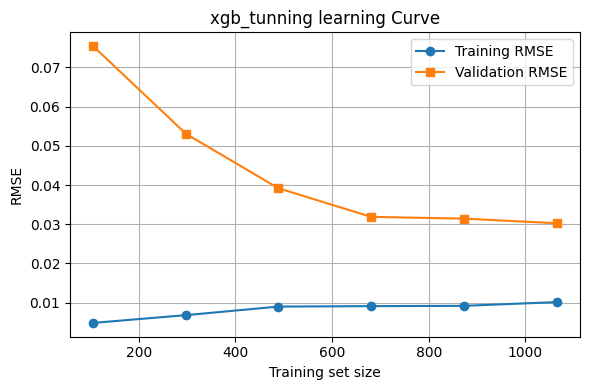

In [43]:
plot_learning_curve(
    best_xgb_model,
    X_train_perm,
    y_train_perm,
    "xgb_tunning learning Curve"
)

In [45]:
logk_pred_xgb = best_xgb_model.predict(X_test_perm)

In [46]:
xgb_metrics = regression_metrics(y_test_perm, logk_pred_xgb)

print("TEST MSE (logK):", xgb_metrics["MSE"])
print("TEST RMSE (logK):", xgb_metrics["RMSE"])
print("TEST R²:", xgb_metrics["R2"])

TEST MSE (logK): 0.0005028731350043706
TEST RMSE (logK): 0.02242483299836078
TEST R²: 0.9891023192599874


## SVR Hyperparameter Tuning

The Support Vector Regression model was optimized using randomized hyperparameter search.

The search considered the C and gamma parameters using the same distributions specified in the original analysis.

In [47]:
svr_random_search = tune_svr(preprocessing_1)

In [48]:
svr_random_search.fit(X_train_perm, y_train_perm)

,estimator,"Pipeline(step...reg', SVR())])"
,param_distributions,"{'svr_reg__C': <scipy.stats....00244F552E3C0>, 'svr_reg__gamma': <scipy.stats....00244F5B790A0>}"
,n_iter,100
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [49]:
print("Best Parameters:", svr_random_search.best_params_)

Best Parameters: {'svr_reg__C': np.float64(4.63629602379294), 'svr_reg__gamma': np.float64(0.08781408196485979)}


In [50]:
best_svr_reg = svr_random_search.best_estimator_

In [51]:
logk_pred_svr = best_svr_reg.predict(X_test_perm)

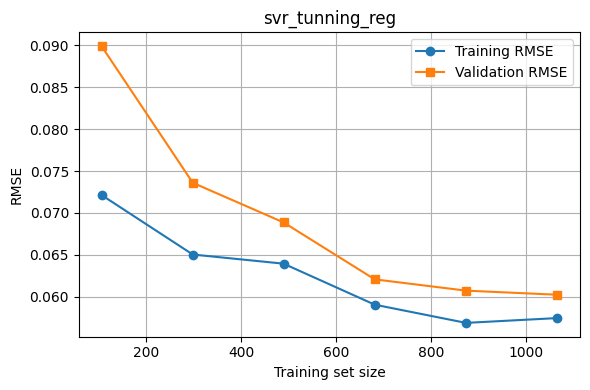

In [52]:
plot_learning_curve(
    best_svr_reg,
    X_train_perm,
    y_train_perm,
    "svr_tunning_reg"
)

In [53]:
svr_metrics = regression_metrics(y_test_perm, logk_pred_svr)

print("TEST MSE (logK):", svr_metrics["MSE"])
print("TEST RMSE (logK):", svr_metrics["RMSE"])
print("TEST R²:", svr_metrics["R2"])

TEST MSE (logK): 0.003184869137434509
TEST RMSE (logK): 0.05643464483306782
TEST R²: 0.9309812263918634


## Comparison of Model Performance

The performance of the optimized Random Forest, XGBoost, and SVR models was compared using MSE, RMSE, and R² calculated on the test dataset.

In [54]:
results = pd.DataFrame(
    {
        "Random Forest": rf_metrics,
        "XGBoost": xgb_metrics,
        "SVR": svr_metrics
    }
).T

results

,RMSE,MSE,R2
Random Forest,0.030879,0.000954,0.979336
XGBoost,0.022425,0.000503,0.989102
SVR,0.056435,0.003185,0.930981


## Actual versus Predicted Log Permeability

The observed and predicted log permeability values were compared graphically for the three optimized models.

In [57]:
from pathlib import Path

Path("results/figures").mkdir(parents=True, exist_ok=True)

In [58]:
scatter_plot(
    actual_logk=y_test_perm,
    pred_logk_list=[logk_pred_rf, logk_pred_xgb, logk_pred_svr],
    model_names=["Random Forest", "XGBoost", "SVR"],
    save_path="results/figures/scatter_plot"
)